# Gujarati Tourism Sentiment Analysis
**NLP Micro Project - SAKEC, Computer Engineering, Sem V** | Parth Bhanushali (124BTCM1058), Yash Panchal (124BTCM1184)

This notebook is the complete experimental part of the project. It:
1. Loads and validates the 500-review Gujarat tourism dataset (Gujarati / English / code-mixed; labels Positive / Neutral / Negative)
2. Performs exploratory data analysis (EDA)
3. Evaluates four approaches against the **gold labels** with **5-fold stratified cross-validation**:
   - **VADER** - English-only lexicon baseline (not trained)
   - **TF-IDF + Logistic Regression** and **TF-IDF + Linear SVM** - classical baselines
   - **XLM-RoBERTa zero-shot** - pretrained multilingual sentiment model (optional, needs `torch` + internet)
   - **Fine-tuned XLM-RoBERTa / MuRIL** - transformer fine-tuning (optional, needs `torch` + NVIDIA GPU)
4. Does error analysis, and exports everything the report and the Streamlit app need into `results/`

**How to run:** `Kernel -> Restart & Run All`. Put `tourism_reviews_dataset_expanded.csv` next to this notebook.
The transformer sections switch themselves off with a clear message if `torch`/GPU is unavailable, so the notebook always finishes.

## 1. Setup and configuration

In [1]:
# Installs only the light libraries (safe to re-run). For the optional transformer sections also install
# PyTorch for your GPU from https://pytorch.org and then:  pip install transformers accelerate sentencepiece
%pip install -q pandas numpy scikit-learn matplotlib seaborn joblib vaderSentiment

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os, re, json, time, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from collections import Counter
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.pipeline import make_pipeline, make_union
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix,
                             cohen_kappa_score, classification_report)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

# ------------------------- CONFIG (edit here) -------------------------
DATA_PATH     = "tourism_reviews_dataset_expanded.csv"   # also looked for in ./data/
RUN_XLMR      = True      # zero-shot XLM-R   (skipped automatically if torch is missing)
RUN_FINETUNE  = True      # fine-tuning       (skipped automatically if no CUDA GPU)
FINETUNE_MODEL = "xlm-roberta-base"   # alternative: "google/muril-base-cased"
EPOCHS, LR, BATCH, MAXLEN = 8, 3e-5, 16, 128
N_FOLDS, SEED = 5, 42
OUT_DIR = "results"
FINAL_MODEL_DIR = os.path.join(OUT_DIR, "xlm_roberta_finetuned")
# ----------------------------------------------------------------------

LABELS = ["Positive", "Neutral", "Negative"]
FIG_DIR = os.path.join(OUT_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)
np.random.seed(SEED)
print("Setup OK")

Setup OK


## 2. Load and validate the dataset

In [3]:
if not os.path.exists(DATA_PATH) and os.path.exists(os.path.join("data", DATA_PATH)):
    DATA_PATH = os.path.join("data", DATA_PATH)
assert os.path.exists(DATA_PATH), f"Cannot find {DATA_PATH}. Put the CSV next to this notebook."

df = pd.read_csv(DATA_PATH)
required = {"review_text", "language", "sentiment"}
assert required <= set(df.columns), f"CSV must contain columns {required}, found {list(df.columns)}"

n_raw = len(df)
df = df.dropna(subset=["review_text", "sentiment"]).drop_duplicates("review_text").reset_index(drop=True)

def clean_text(t):
    """Light cleaning only: URLs, @mentions, extra whitespace. Gujarati script, case and punctuation are kept."""
    t = re.sub(r"http\S+|www\.\S+", "", str(t))
    t = re.sub(r"@\w+", "", t)
    return re.sub(r"\s+", " ", t).strip()

df["clean"] = df["review_text"].map(clean_text)
assert set(df["sentiment"]) <= set(LABELS), f"Unexpected labels: {set(df['sentiment'])}"

print(f"Rows in file: {n_raw} | after dropping nulls/duplicates: {len(df)}")
print("Columns:", list(df.columns))
print("\nSentiment:\n", df["sentiment"].value_counts().to_string())
print("\nLanguage:\n", df["language"].value_counts().to_string())
df.head()

Rows in file: 1498 | after dropping nulls/duplicates: 1498
Columns: ['review_id', 'review_text', 'language', 'category', 'location', 'sentiment', 'clean']

Sentiment:
 sentiment
Positive    504
Negative    497
Neutral     497

Language:
 language
Gujarati    600
Mixed       450
English     448


,review_id,review_text,language,category,location,sentiment,clean
0,1,આ હોટેલ બહુ જ સરસ છે.,Gujarati,Hotel,Ahmedabad,Positive,આ હોટેલ બહુ જ સરસ છે.
1,2,"અમારો અનુભવ ઘણો સારો રહ્યો, સ્ટાફ ખૂબ જ નમ્ર હતો.",Gujarati,Hotel,Vadodara,Positive,"અમારો અનુભવ ઘણો સારો રહ્યો, સ્ટાફ ખૂબ જ નમ્ર હતો."
2,3,રાજકોટમાં રોકાણ માટે આ ઉત્તમ જગ્યા છે. રૂમ મોટ...,Gujarati,Hotel,Rajkot,Positive,રાજકોટમાં રોકાણ માટે આ ઉત્તમ જગ્યા છે. રૂમ મોટ...
3,4,ભુજમાં આ હોટેલ ખરેખર અદભુત છે. અમે બે દિવસ રોક...,Gujarati,Hotel,Bhuj,Positive,ભુજમાં આ હોટેલ ખરેખર અદભુત છે. અમે બે દિવસ રોક...
4,5,મંદિરથી એકદમ નજીક અને સગવડ સારી.,Gujarati,Hotel,Dwarka,Positive,મંદિરથી એકદમ નજીક અને સગવડ સારી.


## 3. Exploratory data analysis

sentiment  Negative  Neutral  Positive   All
language                                    
English         150      148       150   448
Gujarati        197      199       204   600
Mixed           150      150       150   450
All             497      497       504  1498

Category counts:
 category
Hotel                  250
Tourist Attractions    250
Beaches                249
Temple                 209
Street Food            201
Restaurant             198
Pilgrimage Site        141

Number of distinct locations: 24

Review length (words) by sentiment:
           count  mean  min  max
sentiment                       
Positive     504  11.2    4   40
Neutral      497  10.4    3   39
Negative     497  11.4    4   39

Review length (words) by language:
          count  mean  min  max
language                       
English     448  12.6    4   40
Gujarati    600  10.0    4   37
Mixed       450  10.7    3   35


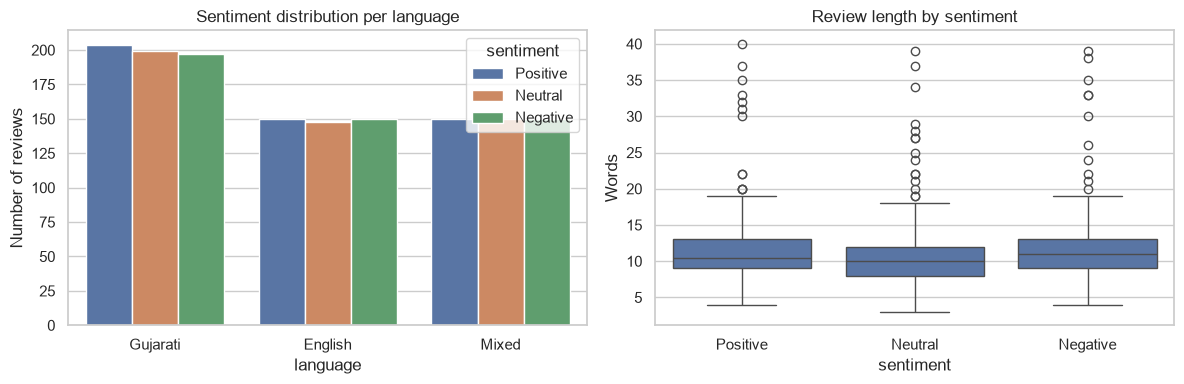

In [4]:
# Language x sentiment table (this is the class balance inside every language)
print(pd.crosstab(df["language"], df["sentiment"], margins=True).to_string())
if "category" in df.columns:
    print("\nCategory counts:\n", df["category"].value_counts().to_string())
if "location" in df.columns:
    print("\nNumber of distinct locations:", df["location"].nunique())

df["n_words"] = df["clean"].str.split().str.len()
print("\nReview length (words) by sentiment:")
print(df.groupby("sentiment")["n_words"].agg(["count", "mean", "min", "max"]).round(1).loc[LABELS].to_string())
print("\nReview length (words) by language:")
print(df.groupby("language")["n_words"].agg(["count", "mean", "min", "max"]).round(1).to_string())

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=df, x="language", hue="sentiment", hue_order=LABELS, ax=ax[0])
ax[0].set_title("Sentiment distribution per language"); ax[0].set_ylabel("Number of reviews")
sns.boxplot(data=df, x="sentiment", y="n_words", order=LABELS, ax=ax[1])
ax[1].set_title("Review length by sentiment"); ax[1].set_ylabel("Words")
plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, "eda_distribution_length.png"), dpi=200); plt.show()

In [5]:
# Most frequent content words per sentiment (printed as tables -> no Gujarati font problems).
GU_STOP = set("છે હતું હતી હતો હતા અને આ તે માટે પણ જ ના ની નો નું માં થી ને એક કે તો પર".split())
ROMAN_STOP = set("chhe che chhi chhu hatu hati hato hata ane ni no nu ma ne ke to pan j aa te".split())  # romanised Gujarati function words in Mixed reviews
STOP = set(ENGLISH_STOP_WORDS) | GU_STOP | ROMAN_STOP
def tokens(t):
    # split on whitespace/punctuation only, so Gujarati vowel signs stay attached to their letters
    return [w for w in re.split(r"[\s\.,!?;:()\"\'\-/]+", t.lower()) if w and w not in STOP and len(w) > 1 and not w.isdigit()]

top = {lab: [f"{w} ({c})" for w, c in Counter(x for t in df.loc[df.sentiment == lab, "clean"] for x in tokens(t)).most_common(12)]
       for lab in LABELS}
pd.DataFrame(top, index=range(1, 13)).rename_axis("rank")

,Positive,Neutral,Negative
rank,,,
1,બહુ (86),temple (32),બહુ (98)
2,ખૂબ (39),રહે (26),નથી (57)
3,એકદમ (37),available (26),સાવ (42)
4,સારી (37),મળે (24),કોઈ (41)
5,મજા (37),અહીંયા (22),ખરાબ (33)
6,આવી (32),beach (20),food (28)
7,સરસ (24),pm (19),water (23)
8,clean (24),નથી (18),નહોતું (21)
9,food (22),પડે (17),બિલકુલ (18)


## 4. Models and evaluation protocol
* **Cross-validation:** 5-fold stratified on *language x sentiment*, so every fold contains the same mix of Gujarati/English/Mixed and Positive/Neutral/Negative. Every reported score is **out-of-fold** (the model never saw the review it is scored on).
* **VADER** and **XLM-R zero-shot** are not trained on our data, so they are scored on all reviews.
* **TF-IDF features:** word 1-2-grams **plus** character 2-5-grams. Character n-grams are robust to Gujarati's rich morphology and to spelling variation in code-mixed text.
* **Metrics:** accuracy, macro-F1 (all three classes weighted equally) and Cohen's kappa **against the gold labels**.

In [6]:
strat = df["language"] + "_" + df["sentiment"]
skf = StratifiedKFold(N_FOLDS, shuffle=True, random_state=SEED)

def score(y, p):
    return dict(accuracy=accuracy_score(y, p),
                macro_f1=f1_score(y, p, average="macro", labels=LABELS),
                kappa=cohen_kappa_score(y, p, labels=LABELS))

def vader_predict(texts):
    try:
        from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
    except ImportError:
        raise ImportError("Run: pip install vaderSentiment")
    a = SentimentIntensityAnalyzer(); out = []
    for t in texts:
        c = a.polarity_scores(t)["compound"]
        out.append("Positive" if c >= .05 else "Negative" if c <= -.05 else "Neutral")
    return np.array(out)

def tfidf_features():
    return make_union(
        TfidfVectorizer(analyzer="word", ngram_range=(1, 2), sublinear_tf=True,
                        token_pattern=r"(?u)[^\s\.,!?;:()\"\']+"),
        TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 5), min_df=2, sublinear_tf=True))

def make_clf(kind):
    clf = (LogisticRegression(max_iter=2000, C=10, class_weight="balanced") if kind == "lr"
           else LinearSVC(C=1.0, class_weight="balanced"))
    return make_pipeline(tfidf_features(), clf)

def cv_sklearn(kind):
    pred = np.empty(len(df), dtype=object); folds = []
    for tr, te in skf.split(df, strat):
        m = make_clf(kind).fit(df["clean"].iloc[tr], df["sentiment"].iloc[tr])
        pred[te] = m.predict(df["clean"].iloc[te])
        folds.append(score(df["sentiment"].iloc[te], pred[te]))
    return pred, folds

results, preds = {}, {}
def record(name, pred, folds=None):
    pred = np.asarray(pred, dtype=object)
    s = score(df["sentiment"], pred)
    r = {"overall": {k: round(float(v), 4) for k, v in s.items()},
         "per_language_accuracy": {lg: round(float(accuracy_score(g["sentiment"], pred[g.index])), 4)
                                   for lg, g in df.groupby("language")},
         "report": classification_report(df["sentiment"], pred, labels=LABELS, output_dict=True, zero_division=0)}
    if folds:
        for m in ("accuracy", "macro_f1"):
            v = [f[m] for f in folds]
            r["overall"][m + "_cv_mean"] = round(float(np.mean(v)), 4)
            r["overall"][m + "_cv_std"] = round(float(np.std(v)), 4)
    results[name] = r; preds[name] = pred
    print(f"{name:32s} accuracy={s['accuracy']:.3f}  macro-F1={s['macro_f1']:.3f}  kappa={s['kappa']:.3f}")

record("VADER (lexicon)", vader_predict(df["clean"]))
for kind, nm in (("lr", "TF-IDF + LogReg"), ("svm", "TF-IDF + LinearSVM")):
    p, f = cv_sklearn(kind); record(nm, p, f)

VADER (lexicon)                  accuracy=0.560  macro-F1=0.551  kappa=0.341
TF-IDF + LogReg                  accuracy=0.887  macro-F1=0.886  kappa=0.830
TF-IDF + LinearSVM               accuracy=0.886  macro-F1=0.886  kappa=0.829


### 4a. XLM-RoBERTa zero-shot (optional)

In [7]:
try:
    if not RUN_XLMR:
        raise RuntimeError("RUN_XLMR is False")
    import torch
    from transformers import pipeline
    dev = 0 if torch.cuda.is_available() else -1
    print("XLM-R zero-shot on", "GPU" if dev == 0 else "CPU (slower, ~minutes)")
    pipe = pipeline("sentiment-analysis", model="cardiffnlp/twitter-xlm-roberta-base-sentiment",
                    device=dev, truncation=True, max_length=256)
    mp = {"positive": "Positive", "neutral": "Neutral", "negative": "Negative",
          "label_2": "Positive", "label_1": "Neutral", "label_0": "Negative"}
    texts, out = df["clean"].tolist(), []
    for i in range(0, len(texts), 16):
        out += [mp[r["label"].lower()] for r in pipe(texts[i:i + 16])]
    record("XLM-R (zero-shot)", out)
except Exception as e:
    print("XLM-R zero-shot SKIPPED ->", type(e).__name__, ":", str(e)[:200])

XLM-R zero-shot on GPU


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


XLM-R (zero-shot)                accuracy=0.882  macro-F1=0.883  kappa=0.823


### 4b. Fine-tuning a multilingual transformer (optional, needs an NVIDIA GPU)

In [8]:
try:
    if not RUN_FINETUNE:
        raise RuntimeError("RUN_FINETUNE is False")
    import torch
    from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
    if not torch.cuda.is_available():
        raise RuntimeError("no CUDA GPU found - fine-tuning on CPU would take hours, skipping")
    dev = "cuda"; use_amp = True
    print(f"Fine-tuning {FINETUNE_MODEL} on {torch.cuda.get_device_name(0)} | {N_FOLDS} folds x {EPOCHS} epochs")
    tok = AutoTokenizer.from_pretrained(FINETUNE_MODEL)
    l2i = {l: i for i, l in enumerate(LABELS)}
    y_all = df["sentiment"].map(l2i).values
    pred_ft = np.empty(len(df), dtype=object); folds_ft = []

    def batch(idx):
        e = tok(list(df["clean"].iloc[idx]), truncation=True, max_length=MAXLEN, padding=True, return_tensors="pt")
        return {k: v.to(dev) for k, v in e.items()}, torch.tensor(y_all[idx]).to(dev)

    for k, (tr, te) in enumerate(skf.split(df, strat), 1):
        torch.manual_seed(SEED + k)
        model = AutoModelForSequenceClassification.from_pretrained(FINETUNE_MODEL, num_labels=3).to(dev)
        opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)
        steps = EPOCHS * int(np.ceil(len(tr) / BATCH))
        sch = get_linear_schedule_with_warmup(opt, int(0.1 * steps), steps)
        try:    scaler = torch.amp.GradScaler("cuda", enabled=use_amp)
        except TypeError: scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
        for ep in range(EPOCHS):
            model.train(); order = np.random.RandomState(SEED + ep).permutation(tr)
            for i in range(0, len(order), BATCH):
                x, y = batch(order[i:i + BATCH])
                with torch.autocast(device_type="cuda", enabled=use_amp):
                    loss = model(**x, labels=y).loss
                opt.zero_grad(); scaler.scale(loss).backward(); scaler.unscale_(opt)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(opt); scaler.update(); sch.step()
        model.eval(); ps = []
        with torch.no_grad():
            for i in range(0, len(te), 32):
                x, _ = batch(te[i:i + 32]); ps += model(**x).logits.argmax(-1).cpu().tolist()
        pred_ft[te] = [LABELS[i] for i in ps]
        folds_ft.append(score(df["sentiment"].iloc[te], pred_ft[te]))
        print(f"  fold {k}/{N_FOLDS}: accuracy={folds_ft[-1]['accuracy']:.3f}  macro-F1={folds_ft[-1]['macro_f1']:.3f}")
        del model, opt; torch.cuda.empty_cache()
    record(f"Fine-tuned {FINETUNE_MODEL.split('/')[-1]}", pred_ft, folds_ft)
except Exception as e:
    print("Fine-tuning SKIPPED ->", type(e).__name__, ":", str(e)[:300])

Fine-tuning xlm-roberta-base on NVIDIA GeForce RTX 5050 Laptop GPU | 5 folds x 8 epochs


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  fold 1/5: accuracy=0.970  macro-F1=0.970


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  fold 4/5: accuracy=0.960  macro-F1=0.960


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  fold 5/5: accuracy=0.957  macro-F1=0.957
Fine-tuned xlm-roberta-base      accuracy=0.961  macro-F1=0.961  kappa=0.941


## 5. Results

,Model,Accuracy,Macro-F1,Kappa vs gold,CV acc (mean +/- std),Acc English,Acc Gujarati,Acc Mixed
0,VADER (lexicon),0.560,0.551,0.341,n/a (not trained),0.725,0.340,0.689
1,TF-IDF + LogReg,0.886,0.886,0.830,0.886 +/- 0.008,0.859,0.898,0.898
2,TF-IDF + LinearSVM,0.886,0.886,0.829,0.886 +/- 0.014,0.857,0.897,0.900
3,XLM-R (zero-shot),0.882,0.883,0.823,n/a (not trained),0.931,0.842,0.887
4,Fine-tuned xlm-roberta-base,0.961,0.961,0.941,0.961 +/- 0.009,0.953,0.962,0.967


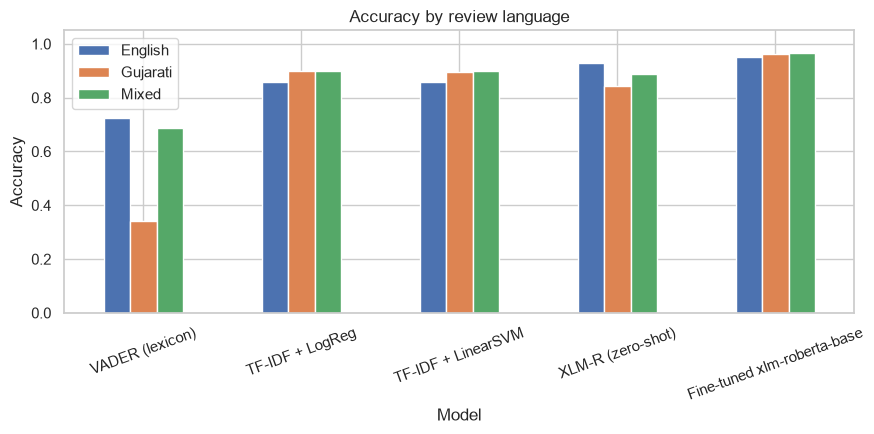

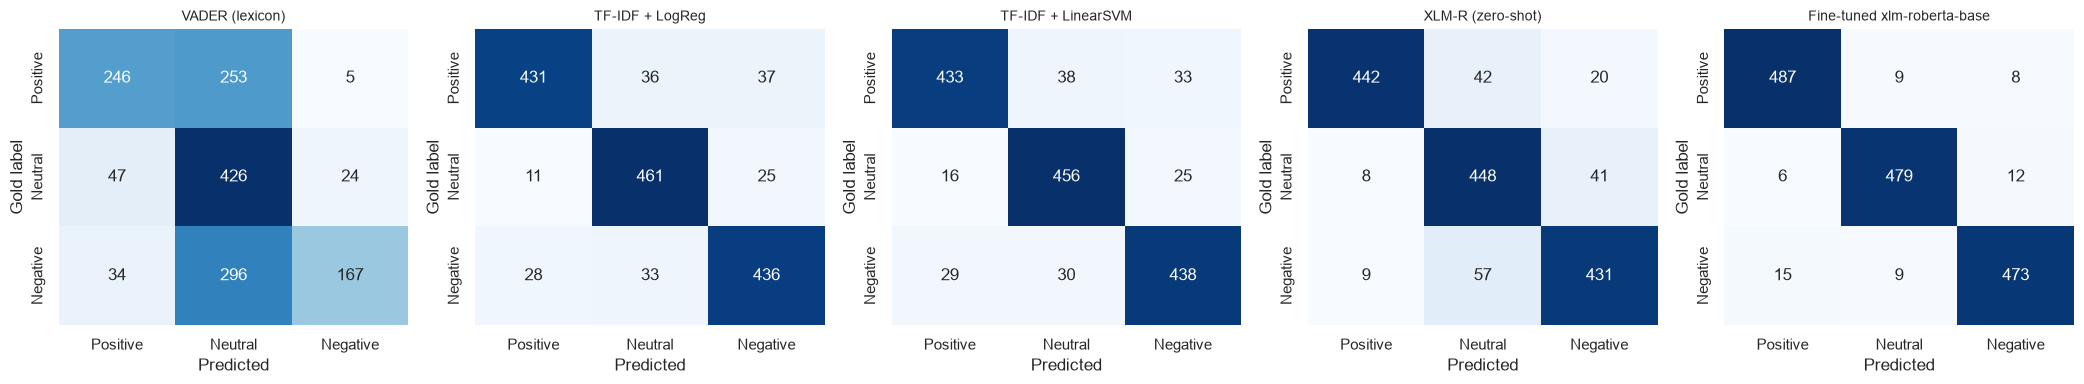

In [9]:
rows = []
for n, r in results.items():
    o = r["overall"]
    rows.append({"Model": n, "Accuracy": o["accuracy"], "Macro-F1": o["macro_f1"], "Kappa vs gold": o["kappa"],
                 "CV acc (mean +/- std)": (f"{o['accuracy_cv_mean']:.3f} +/- {o['accuracy_cv_std']:.3f}" if "accuracy_cv_mean" in o else "n/a (not trained)"),
                 **{f"Acc {lg}": v for lg, v in r["per_language_accuracy"].items()}})
table = pd.DataFrame(rows)
table.to_csv(os.path.join(OUT_DIR, "metrics_table.csv"), index=False)
display(table.round(3))

lang_cols = [c for c in table.columns if c.startswith("Acc ")]
ax = table.set_index("Model")[lang_cols].rename(columns=lambda c: c[4:]).plot.bar(figsize=(9, 4.5), rot=20)
ax.set_ylabel("Accuracy"); ax.set_ylim(0, 1.05); ax.set_title("Accuracy by review language")
plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, "accuracy_by_language.png"), dpi=200); plt.show()

fig, axes = plt.subplots(1, len(results), figsize=(4.2 * len(results), 4))
axes = np.atleast_1d(axes)
for ax, (n, p) in zip(axes, preds.items()):
    sns.heatmap(confusion_matrix(df["sentiment"], p, labels=LABELS), annot=True, fmt="d", cmap="Blues",
                xticklabels=LABELS, yticklabels=LABELS, cbar=False, ax=ax)
    ax.set_title(n, fontsize=10); ax.set_xlabel("Predicted"); ax.set_ylabel("Gold label")
plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, "confusion_matrices.png"), dpi=200); plt.show()

## 6. Error analysis

In [10]:
trained = [n for n in results if n not in ("VADER (lexicon)", "XLM-R (zero-shot)")]
best = max(trained, key=lambda n: results[n]["overall"]["macro_f1"])
print("Best trained model by macro-F1:", best)
err = df.assign(predicted=preds[best])
err = err[err["sentiment"] != err["predicted"]]
print(f"Misclassified: {len(err)} of {len(df)} ({len(err)/len(df):.1%})\n")
print("Errors by language:\n", err["language"].value_counts().to_string())
print("\nMost common confusions (gold -> predicted):")
print(err.groupby(["sentiment", "predicted"]).size().sort_values(ascending=False).to_string())
print("\nPer-class report for", best)
print(pd.DataFrame(results[best]["report"]).T.round(3).loc[LABELS + ["macro avg"]].to_string())
err[["language", "sentiment", "predicted", "review_text"]].head(12)

Best trained model by macro-F1: Fine-tuned xlm-roberta-base
Misclassified: 59 of 1498 (3.9%)

Errors by language:
 language
Gujarati    23
English     21
Mixed       15

Most common confusions (gold -> predicted):
sentiment  predicted
Negative   Positive     15
Neutral    Negative     12
Negative   Neutral       9
Positive   Neutral       9
           Negative      8
Neutral    Positive      6

Per-class report for Fine-tuned xlm-roberta-base
           precision  recall  f1-score  support
Positive       0.959   0.966     0.962    504.0
Neutral        0.964   0.964     0.964    497.0
Negative       0.959   0.952     0.956    497.0
macro avg      0.961   0.961     0.961   1498.0


,language,sentiment,predicted,review_text
39,Gujarati,Neutral,Negative,હોટેલમાં લિફ્ટની સુવિધા નથી.
135,Gujarati,Neutral,Negative,"પાર્કિંગ માટે જગ્યા નથી, તમારે જાતે વ્યવસ્થા ક..."
158,English,Negative,Positive,Wow... best restaurant if you enjoy waiting tw...
220,Gujarati,Negative,Positive,મંદિરની બહાર દુકાનદારો બહુ જ હેરાન કરે છે અને ...
328,Gujarati,Neutral,Positive,આશ્રમમાં પ્રવેશ માટે કોઈ ટિકિટ લેવાની હોતી નથી...
376,Mixed,Positive,Negative,Ropeway ride was thrilling! Darshan pan bahu s...
381,Mixed,Negative,Positive,Parkig mate koi proper space nathi. Traffic po...
382,Mixed,Negative,Neutral,Weekend per bahu j rush hoy chhe. Shantithi ph...
385,Mixed,Negative,Neutral,Guide na name par lut fad chale chhe. Informat...
388,Mixed,Negative,Neutral,Bahu kachro hato andar.


## 7. Export for the report and the Streamlit app

In [11]:
# The app needs a confidence score; only LogReg provides predict_proba, so the exported model is always LogReg.
final = make_clf("lr").fit(df["clean"], df["sentiment"])
joblib.dump({"model": final, "labels": LABELS, "name": "TF-IDF + LogReg"}, os.path.join(OUT_DIR, "model.joblib"))

# Train one final deployable XLM-R model on ALL labeled reviews. CV above is only for evaluation.
if RUN_FINETUNE and "pred_ft" in globals():
    os.makedirs(FINAL_MODEL_DIR, exist_ok=True)
    deploy_tok = AutoTokenizer.from_pretrained(FINETUNE_MODEL)
    deploy_model = AutoModelForSequenceClassification.from_pretrained(FINETUNE_MODEL, num_labels=len(LABELS), id2label={i: label for i, label in enumerate(LABELS)}, label2id={label: i for i, label in enumerate(LABELS)}).to("cuda")
    deploy_opt = torch.optim.AdamW(deploy_model.parameters(), lr=LR, weight_decay=0.01)
    deploy_steps = EPOCHS * int(np.ceil(len(df) / BATCH))
    deploy_sch = get_linear_schedule_with_warmup(deploy_opt, int(0.1 * deploy_steps), deploy_steps)
    try: deploy_scaler = torch.amp.GradScaler("cuda", enabled=True)
    except TypeError: deploy_scaler = torch.cuda.amp.GradScaler(enabled=True)
    deploy_y = torch.tensor(df["sentiment"].map({label: i for i, label in enumerate(LABELS)}).values).to("cuda")
    for epoch in range(EPOCHS):
        deploy_model.train(); order = np.random.RandomState(SEED + 100 + epoch).permutation(len(df))
        for start in range(0, len(order), BATCH):
            idx = order[start:start + BATCH]
            enc = deploy_tok(list(df["clean"].iloc[idx]), truncation=True, max_length=MAXLEN, padding=True, return_tensors="pt")
            enc = {key: value.to("cuda") for key, value in enc.items()}
            with torch.autocast(device_type="cuda", enabled=True): loss = deploy_model(**enc, labels=deploy_y[idx]).loss
            deploy_opt.zero_grad(); deploy_scaler.scale(loss).backward(); deploy_scaler.unscale_(deploy_opt); torch.nn.utils.clip_grad_norm_(deploy_model.parameters(), 1.0); deploy_scaler.step(deploy_opt); deploy_scaler.update(); deploy_sch.step()
        print(f"final model epoch {epoch + 1}/{EPOCHS} loss={loss.item():.4f}")
    deploy_model.save_pretrained(FINAL_MODEL_DIR, safe_serialization=True); deploy_tok.save_pretrained(FINAL_MODEL_DIR)
    json.dump({"model_name": FINETUNE_MODEL, "labels": LABELS, "max_length": MAXLEN, "n_reviews": int(len(df)), "epochs": EPOCHS}, open(os.path.join(FINAL_MODEL_DIR, "metadata.json"), "w"), indent=2)
    print("Saved final XLM-R model to", os.path.abspath(FINAL_MODEL_DIR))


json.dump({"n_reviews": int(len(df)), "folds": N_FOLDS, "seed": SEED, "best_trained_model": best, "models": results},
          open(os.path.join(OUT_DIR, "metrics.json"), "w"), indent=2, ensure_ascii=False)

keep = [c for c in ("review_id", "review_text", "language", "category", "location", "sentiment") if c in df.columns]
out = df[keep].copy()
for n, p in preds.items():
    out[n] = p
out.to_csv(os.path.join(OUT_DIR, "predictions.csv"), index=False, encoding="utf-8-sig")
print("Saved to", os.path.abspath(OUT_DIR), ":", sorted(os.listdir(OUT_DIR)))

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


final model epoch 1/8 loss=0.4184
final model epoch 2/8 loss=0.5124
final model epoch 3/8 loss=0.0023
final model epoch 4/8 loss=0.0042
final model epoch 5/8 loss=0.0014
final model epoch 6/8 loss=0.0016
final model epoch 7/8 loss=0.0005
final model epoch 8/8 loss=0.0006


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved final XLM-R model to c:\Users\Yash\OneDrive\Desktop\NPL main\results\xlm_roberta_finetuned
Saved to c:\Users\Yash\OneDrive\Desktop\NPL main\results : ['figures', 'metrics.json', 'metrics_table.csv', 'model.joblib', 'predictions.csv', 'xlm_roberta_finetuned']


## 8. Try your own review

In [12]:
bundle = joblib.load(os.path.join(OUT_DIR, "model.joblib"))
def predict(text):
    m = bundle["model"]; p = m.predict_proba([clean_text(text)])[0]
    return m.classes_[p.argmax()], {c: round(float(x), 3) for c, x in zip(m.classes_, p)}

for t in ["The hotel was dirty and the staff was very rude",
          "ગીર જંગલ સફારી ખૂબ સરસ હતી, amazing experience!",
          "Ticket counter opens at 9 AM near the main gate"]:
    print(t, "->", predict(t))

The hotel was dirty and the staff was very rude -> ('Negative', {'Negative': 0.982, 'Neutral': 0.002, 'Positive': 0.016})
ગીર જંગલ સફારી ખૂબ સરસ હતી, amazing experience! -> ('Positive', {'Negative': 0.008, 'Neutral': 0.001, 'Positive': 0.991})
Ticket counter opens at 9 AM near the main gate -> ('Neutral', {'Negative': 0.021, 'Neutral': 0.968, 'Positive': 0.012})
